In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             recall_score, balanced_accuracy_score, f1_score)

In [2]:
from datasets import load_dataset

dataset = load_dataset("marmal88/skin_cancer")

print(dataset)

README.md:   0%|          | 0.00/3.24k [00:00<?, ?B/s]

data/train-00000-of-00005-7eed077f2f8e6d(…): reconstructing file:   0%|          |  0.00B /  521MB            

data/train-00000-of-00005-7eed077f2f8e6d(…): downloading bytes:           |  0.00B            

data/train-00001-of-00005-50ba64fd20294b(…): reconstructing file:   0%|          |  0.00B /  525MB            

data/train-00001-of-00005-50ba64fd20294b(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-61e7cf54bf274ae(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9577 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2492 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1285 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 9577
    })
    validation: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 2492
    })
    test: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 1285
    })
})


In [3]:
df = pd.DataFrame(dataset['train'])
print(df.head())
df.shape

                                               image      image_id  \
0  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024329   
1  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024372   
2  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024418   
3  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024450   
4  <PIL.JpegImagePlugin.JpegImageFile image mode=...  ISIC_0024463   

     lesion_id                 dx dx_type   age     sex     localization  
0  HAM_0002954  actinic_keratoses   histo  75.0  female  lower extremity  
1  HAM_0005389  actinic_keratoses   histo  70.0    male  lower extremity  
2  HAM_0003380  actinic_keratoses   histo  75.0  female  lower extremity  
3  HAM_0005505  actinic_keratoses   histo  50.0    male  upper extremity  
4  HAM_0004568  actinic_keratoses   histo  50.0    male  upper extremity  


(9577, 8)

In [4]:
df.info()
df.describe().T
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9577 entries, 0 to 9576
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image         9577 non-null   object 
 1   image_id      9577 non-null   object 
 2   lesion_id     9577 non-null   object 
 3   dx            9577 non-null   object 
 4   dx_type       9577 non-null   object 
 5   age           9522 non-null   float64
 6   sex           9577 non-null   object 
 7   localization  9577 non-null   object 
dtypes: float64(1), object(7)
memory usage: 598.7+ KB


['image',
 'image_id',
 'lesion_id',
 'dx',
 'dx_type',
 'age',
 'sex',
 'localization']

In [5]:
print("\nMissing values per column:")
display(df.isnull().sum())

print('\nDuplicate values per column:')
display(df.drop(columns=['image']).duplicated().sum())


Missing values per column:


,0
image,0
image_id,0
lesion_id,0
dx,0
dx_type,0
age,55
sex,0
localization,0



Duplicate values per column:


np.int64(0)

In [6]:
print('\nFill missing values in \'age\' with the most common age:')
df['age'] = df['age'].fillna(df['age'].median())
display(df.isnull().sum())


Fill missing values in 'age' with the most common age:


,0
image,0
image_id,0
lesion_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0


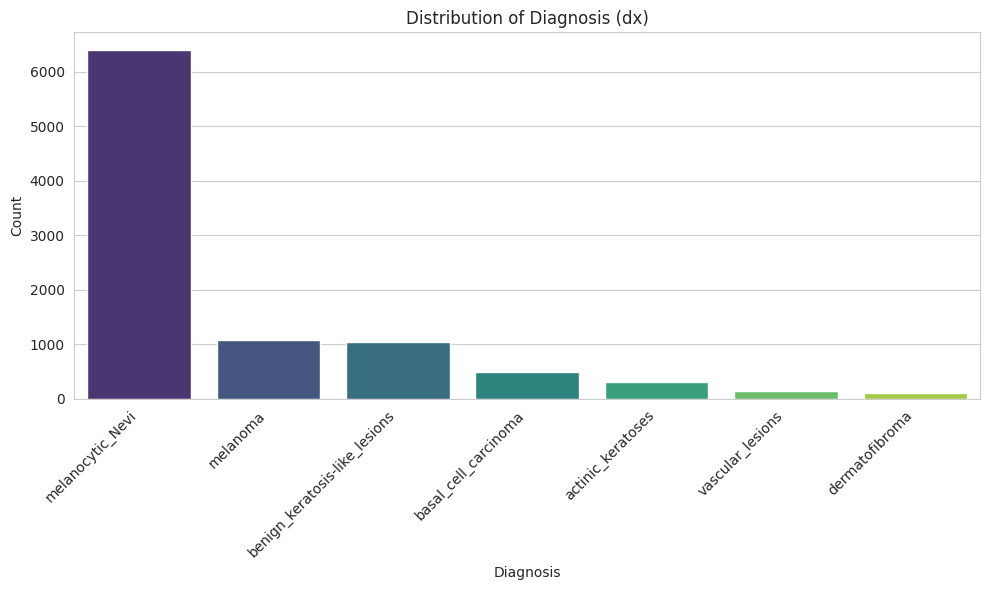

In [7]:
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

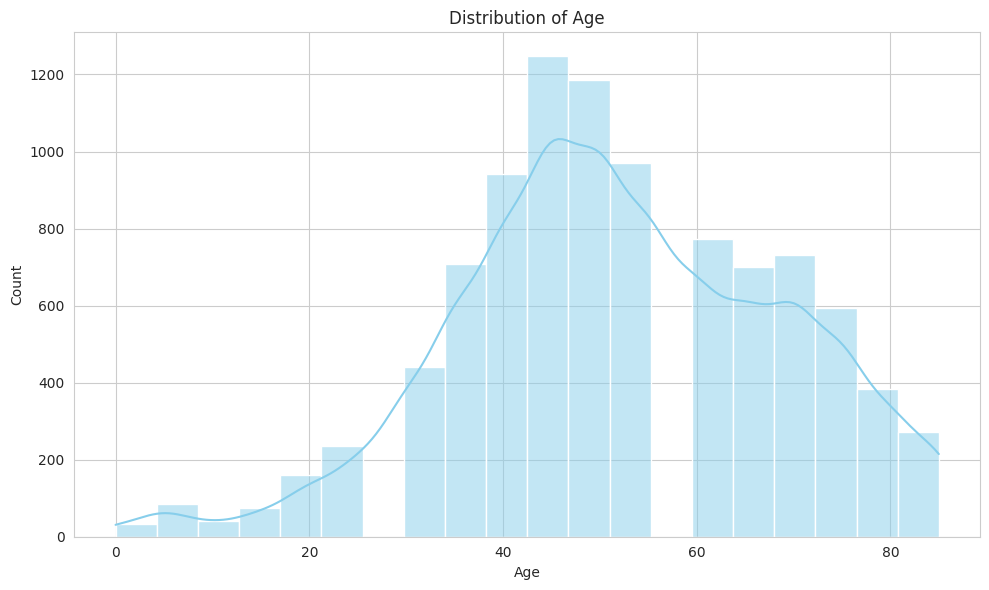

In [8]:
# 2. Distribution of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

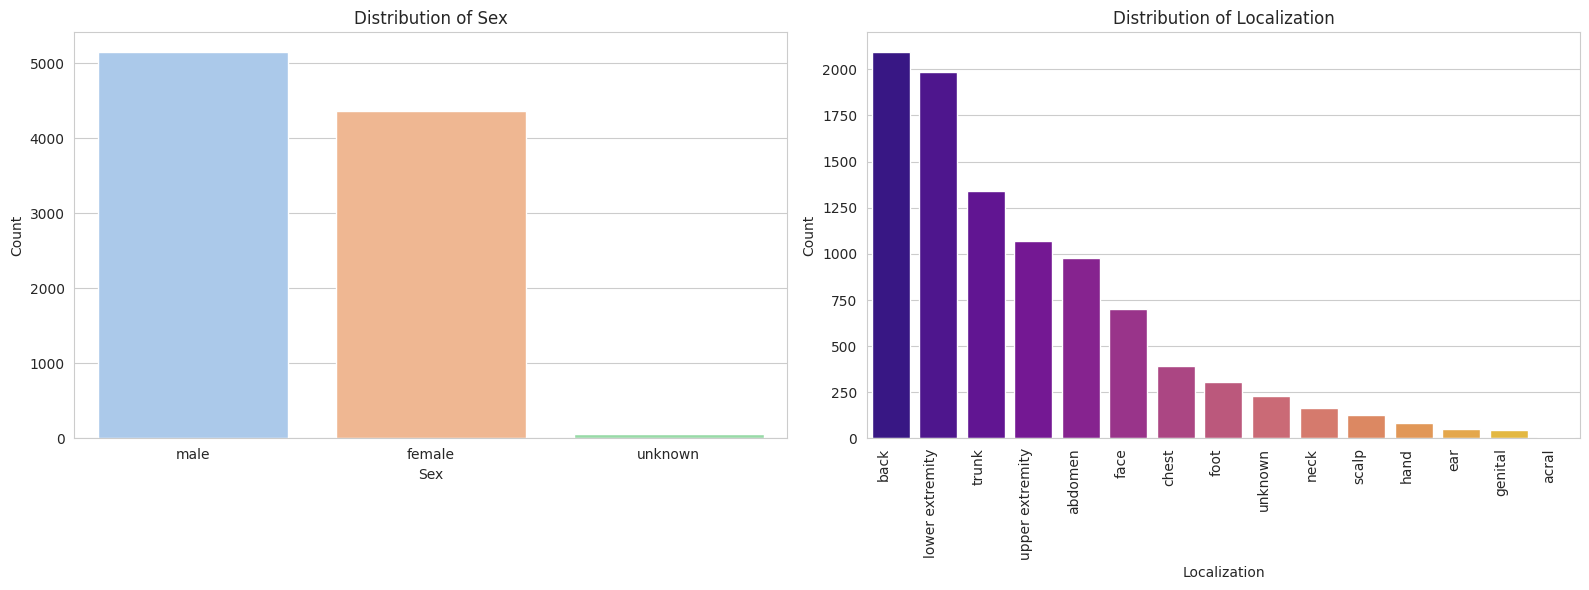

In [9]:
# 3. Distributions of 'sex' and 'localization'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='sex', ax=axes[0], palette='pastel', order=df['sex'].value_counts().index)
axes[0].set_title('Distribution of Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='localization', ax=axes[1], palette='plasma', order=df['localization'].value_counts().index)
axes[1].set_title('Distribution of Localization')
axes[1].set_xlabel('Localization')
axes[1].set_ylabel('Count')
plt.setp(axes[1].get_xticklabels(), rotation=90, horizontalalignment='right')

plt.tight_layout()
plt.show()

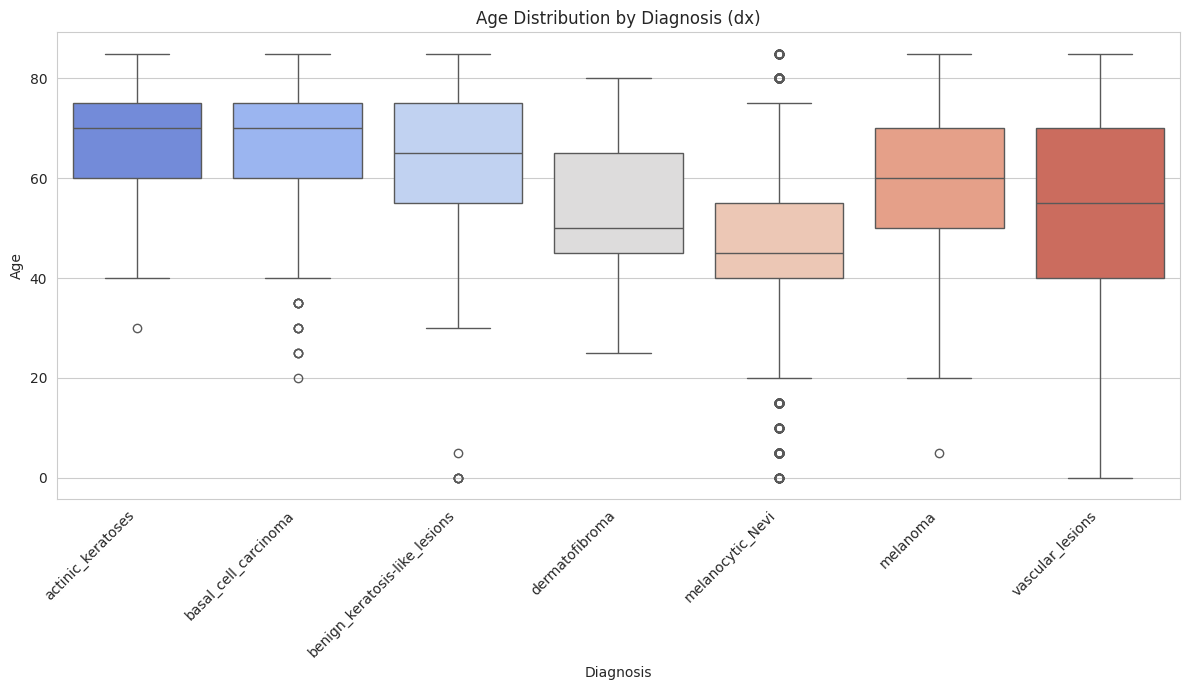

In [10]:
# 4. Age distribution by 'dx'
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='dx', y='age', palette='coolwarm')
plt.title('Age Distribution by Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
df_encoded = pd.get_dummies(df, columns=['dx'], prefix='dx')

# Display the first few rows of the DataFrame with the new encoded columns
display(df_encoded.head())

# Display the names of the new columns created by one-hot encoding
print(f"\nNew columns created: {df_encoded.columns[df_encoded.columns.str.startswith('dx_')].tolist()}")

,image,image_id,lesion_id,dx_type,age,sex,localization,dx_actinic_keratoses,dx_basal_cell_carcinoma,dx_benign_keratosis-like_lesions,dx_dermatofibroma,dx_melanocytic_Nevi,dx_melanoma,dx_vascular_lesions
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024329,HAM_0002954,histo,75.0,female,lower extremity,True,False,False,False,False,False,False
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024372,HAM_0005389,histo,70.0,male,lower extremity,True,False,False,False,False,False,False
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024418,HAM_0003380,histo,75.0,female,lower extremity,True,False,False,False,False,False,False
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024450,HAM_0005505,histo,50.0,male,upper extremity,True,False,False,False,False,False,False
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,ISIC_0024463,HAM_0004568,histo,50.0,male,upper extremity,True,False,False,False,False,False,False



New columns created: ['dx_type', 'dx_actinic_keratoses', 'dx_basal_cell_carcinoma', 'dx_benign_keratosis-like_lesions', 'dx_dermatofibroma', 'dx_melanocytic_Nevi', 'dx_melanoma', 'dx_vascular_lesions']


## Prepare labels to split Train/Test sets and handle Class Imbalance

In [12]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["dx"])
class_names = label_encoder.classes_

print("Classes:", list(enumerate(class_names)))
print("Label shape:", y.shape)

Classes: [(0, 'actinic_keratoses'), (1, 'basal_cell_carcinoma'), (2, 'benign_keratosis-like_lesions'), (3, 'dermatofibroma'), (4, 'melanocytic_Nevi'), (5, 'melanoma'), (6, 'vascular_lesions')]
Label shape: (9577,)


In [13]:
def image_to_array(example, size=(32, 32)):
    """Convert a Hugging Face/Pillow image to a normalized RGB array."""
    image = example["image"].convert("RGB").resize(size)
    return np.asarray(image, dtype=np.float32) / 255.0

# Decode and resize images only when they are actually needed for modeling.
X = np.stack([image_to_array(example) for example in dataset["train"]])

print("Image array shape:", X.shape)
print("Image value range:", float(X.min()), "to", float(X.max()))

Image array shape: (9577, 32, 32, 3)
Image value range: 0.0 to 1.0


In [14]:
# Split the dataset into train/test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (7661, 32, 32, 3) (7661,)
Test set: (1916, 32, 32, 3) (1916,)


## Part 2 — Outlier inspection and baseline models (added section)

The original notebook cells above already convert images to RGB, resize them to **32 × 32 × 3**, scale pixels from **0–255** to **0–1**, and create the team's 80/20 stratified split. This added section uses those existing `X_train`, `X_test`, `y_train`, and `y_test` objects without changing them.


In [15]:
# Imports used only by the added Part 2 section
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score


### Inspect image outliers

The checks below do not change or remove records from the team's existing arrays. Potential brightness and contrast outliers are flagged for visual inspection and retained because unusual appearance may contain meaningful lesion information.


In [16]:
# X was created by the original preprocessing cell and is already scaled to 0–1.
image_quality_df = pd.DataFrame({
    "row_index": np.arange(len(X)),
    "image_id": dataset["train"]["image_id"],
    "lesion_id": dataset["train"]["lesion_id"],
    "dx": dataset["train"]["dx"],
    "brightness": X.mean(axis=(1, 2, 3)),
    "contrast": X.std(axis=(1, 2, 3)),
})


def iqr_outlier_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)


image_quality_df["brightness_outlier"] = iqr_outlier_mask(
    image_quality_df["brightness"]
)
image_quality_df["contrast_outlier"] = iqr_outlier_mask(
    image_quality_df["contrast"]
)
image_quality_df["potential_outlier"] = (
    image_quality_df["brightness_outlier"]
    | image_quality_df["contrast_outlier"]
)

print("Total images checked:", len(image_quality_df))
print("Brightness outliers flagged:", int(image_quality_df["brightness_outlier"].sum()))
print("Contrast outliers flagged:", int(image_quality_df["contrast_outlier"].sum()))
print("Total potential outliers flagged:", int(image_quality_df["potential_outlier"].sum()))
display(image_quality_df[["brightness", "contrast"]].describe())


Total images checked: 9577
Brightness outliers flagged: 79
Contrast outliers flagged: 11
Total potential outliers flagged: 90


,brightness,contrast
count,9577.000000,9577.000000
mean,0.626811,0.158089
std,0.075101,0.045650
min,0.249272,0.039369
25%,0.575770,0.121561
50%,0.626435,0.162098
75%,0.677253,0.192352
max,0.908923,0.349866


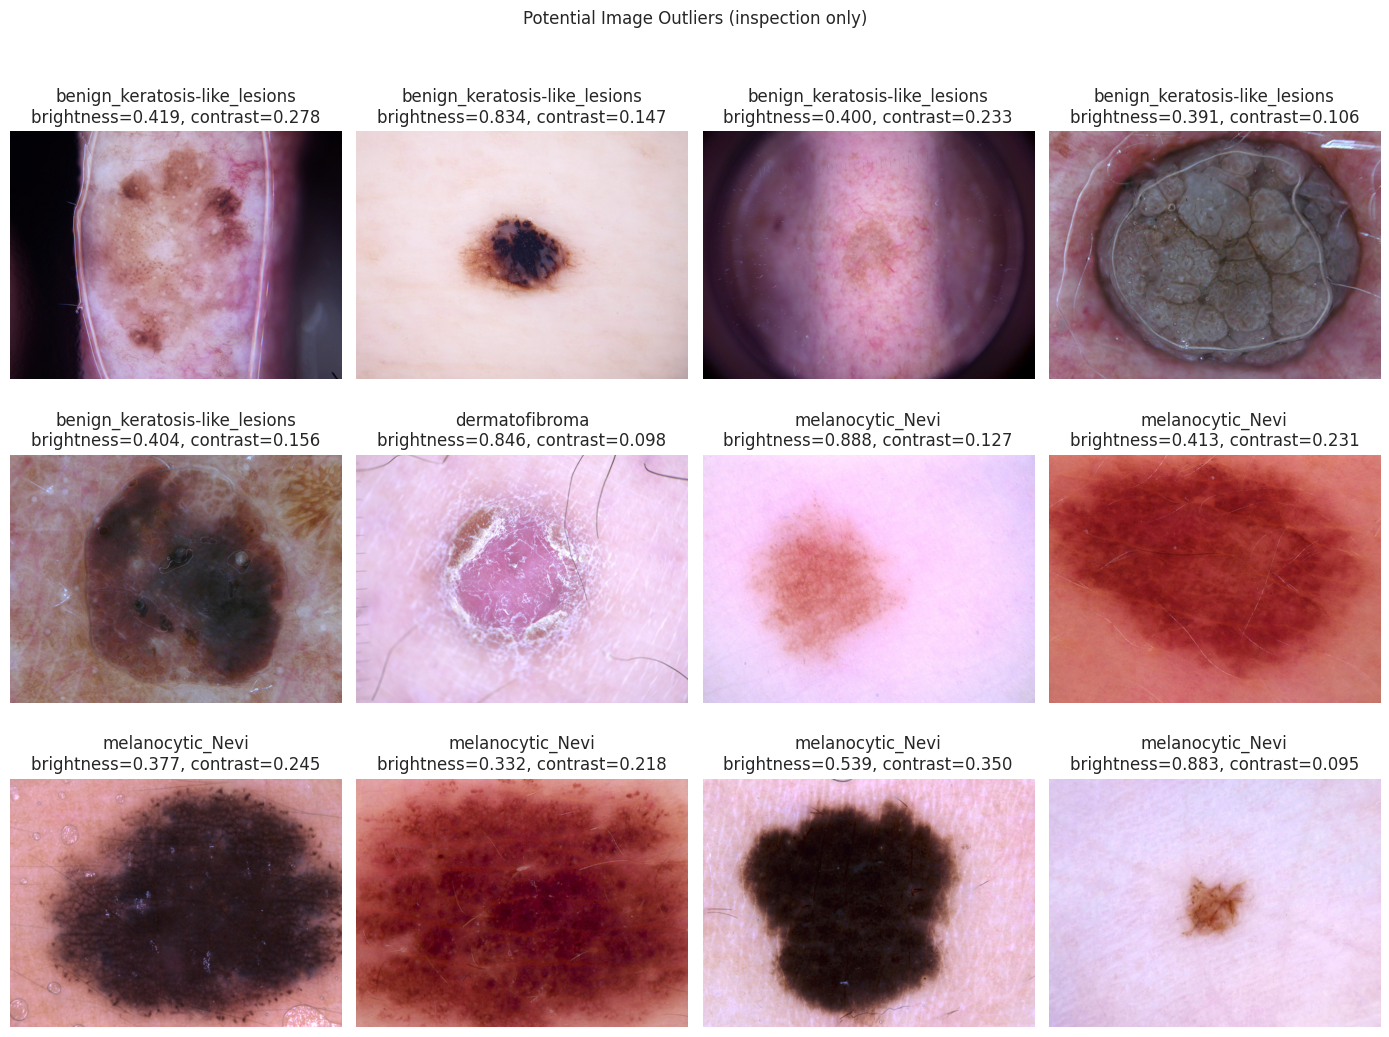

Potential outliers were retained; the existing X and y arrays were not changed.


In [17]:
potential_outliers = image_quality_df[
    image_quality_df["potential_outlier"]
].head(12)

if potential_outliers.empty:
    print("No brightness or contrast outliers were flagged.")
else:
    columns = 4
    rows = int(np.ceil(len(potential_outliers) / columns))
    plt.figure(figsize=(14, 3.5 * rows))

    for plot_number, (_, record) in enumerate(potential_outliers.iterrows(), start=1):
        original_row = dataset["train"][int(record["row_index"])]
        plt.subplot(rows, columns, plot_number)
        plt.imshow(original_row["image"])
        plt.title(
            f"{record['dx']}\n"
            f"brightness={record['brightness']:.3f}, "
            f"contrast={record['contrast']:.3f}"
        )
        plt.axis("off")

    plt.suptitle("Potential Image Outliers (inspection only)", y=1.02)
    plt.tight_layout()
    plt.show()

print("Potential outliers were retained; the existing X and y arrays were not changed.")


### Majority Class Baseline and Logistic Regression

Both added models use the team's original train/test split. Logistic Regression intentionally uses no class weights because class-imbalance handling remains in Part 3.


In [18]:
ALL_LABELS = np.arange(len(class_names))
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened test shape:", X_test_flat.shape)


def evaluate_part2_model(model, model_name, X_eval, y_eval):
    predictions = model.predict(X_eval)
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, predictions),
        "Macro Precision": precision_score(
            y_eval, predictions, labels=ALL_LABELS,
            average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_eval, predictions, labels=ALL_LABELS,
            average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_eval, predictions, labels=ALL_LABELS,
            average="macro", zero_division=0
        ),
    }

    print(f"\n{model_name}")
    print("=" * len(model_name))
    for metric, value in result.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_eval,
        predictions,
        labels=ALL_LABELS,
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_eval, predictions, labels=ALL_LABELS)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return result, predictions


Flattened training shape: (7661, 3072)
Flattened test shape: (1916, 3072)


Majority class: melanocytic_Nevi

Majority Class Baseline
Accuracy: 0.6686
Balanced Accuracy: 0.1429
Macro Precision: 0.0955
Macro Recall: 0.1429
Macro F1: 0.1145

Classification Report:
                               precision    recall  f1-score   support

            actinic_keratoses     0.0000    0.0000    0.0000        63
         basal_cell_carcinoma     0.0000    0.0000    0.0000        98
benign_keratosis-like_lesions     0.0000    0.0000    0.0000       210
               dermatofibroma     0.0000    0.0000    0.0000        22
             melanocytic_Nevi     0.6686    1.0000    0.8014      1281
                     melanoma     0.0000    0.0000    0.0000       215
             vascular_lesions     0.0000    0.0000    0.0000        27

                     accuracy                         0.6686      1916
                    macro avg     0.0955    0.1429    0.1145      1916
                 weighted avg     0.4470    0.6686    0.5358      1916



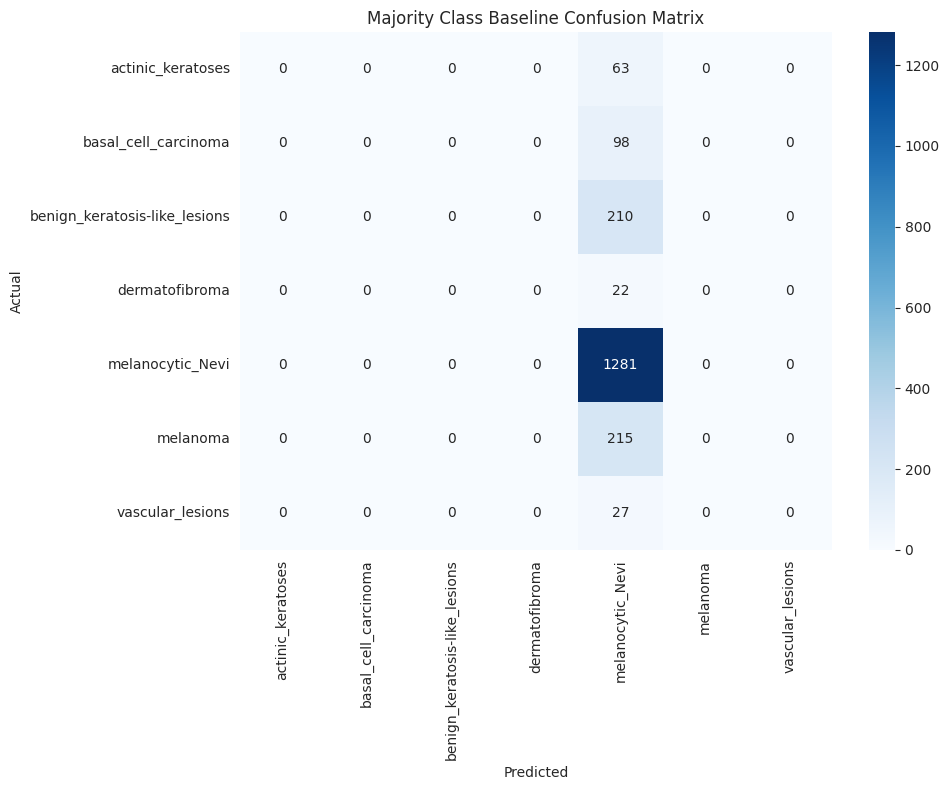

In [19]:
majority_baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=42,
)
majority_baseline.fit(X_train_flat, y_train)

majority_class_id = int(majority_baseline.predict(X_train_flat[:1])[0])
print("Majority class:", class_names[majority_class_id])

majority_result, majority_predictions = evaluate_part2_model(
    majority_baseline,
    "Majority Class Baseline",
    X_test_flat,
    y_test,
)


Training Logistic Regression...

Logistic Regression
Accuracy: 0.6968
Balanced Accuracy: 0.3067
Macro Precision: 0.5393
Macro Recall: 0.3067
Macro F1: 0.3394

Classification Report:
                               precision    recall  f1-score   support

            actinic_keratoses     0.1905    0.0635    0.0952        63
         basal_cell_carcinoma     0.4458    0.3776    0.4088        98
benign_keratosis-like_lesions     0.3907    0.2810    0.3269       210
               dermatofibroma     1.0000    0.0455    0.0870        22
             melanocytic_Nevi     0.7630    0.9251    0.8363      1281
                     melanoma     0.4468    0.1953    0.2718       215
             vascular_lesions     0.5385    0.2593    0.3500        27

                     accuracy                         0.6968      1916
                    macro avg     0.5393    0.3067    0.3394      1916
                 weighted avg     0.6513    0.6968    0.6554      1916



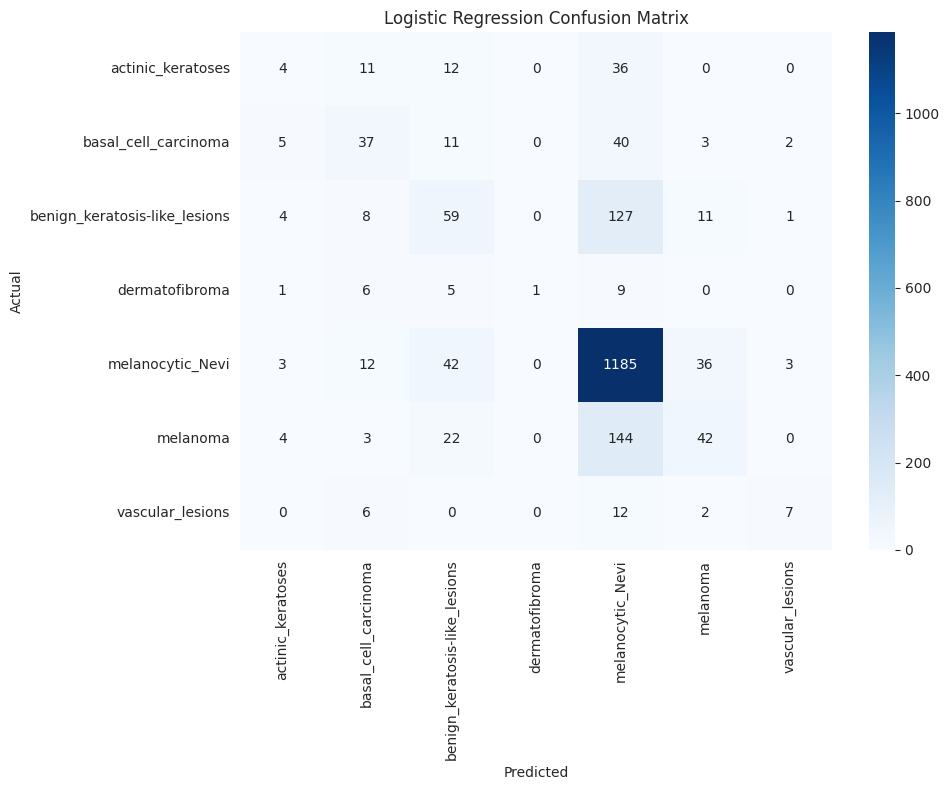

In [20]:
RUN_LOGISTIC_REGRESSION = True

if RUN_LOGISTIC_REGRESSION:
    logistic_model = LogisticRegression(
        solver="saga",
        C=1.0,
        max_iter=500,
        tol=1e-3,
        class_weight=None,
        random_state=42,
    )

    print("Training Logistic Regression...")
    logistic_model.fit(X_train_flat, y_train)

    logistic_result, logistic_predictions = evaluate_part2_model(
        logistic_model,
        "Logistic Regression",
        X_test_flat,
        y_test,
    )
else:
    logistic_model = None
    logistic_result = None
    print("Logistic Regression skipped.")


In [27]:
from sklearn.metrics import log_loss

# Majority Class Baseline Log Loss
majority_probabilities = majority_baseline.predict_proba(X_test_flat)

majority_loss = log_loss(
    y_test,
    majority_probabilities,
    labels=ALL_LABELS
)

# Logistic Regression Log Loss
logistic_probabilities = logistic_model.predict_proba(X_test_flat)

logistic_loss = log_loss(
    y_test,
    logistic_probabilities,
    labels=ALL_LABELS
)

print(f"Majority Class Baseline Log Loss: {majority_loss:.4f}")
print(f"Logistic Regression Log Loss: {logistic_loss:.4f}")

Majority Class Baseline Log Loss: 11.9456
Logistic Regression Log Loss: 0.8202


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Log Loss
0,Majority Class Baseline,0.6686,0.1429,0.0955,0.1429,0.1145,11.9456
1,Logistic Regression,0.6968,0.3067,0.5393,0.3067,0.3394,0.8202


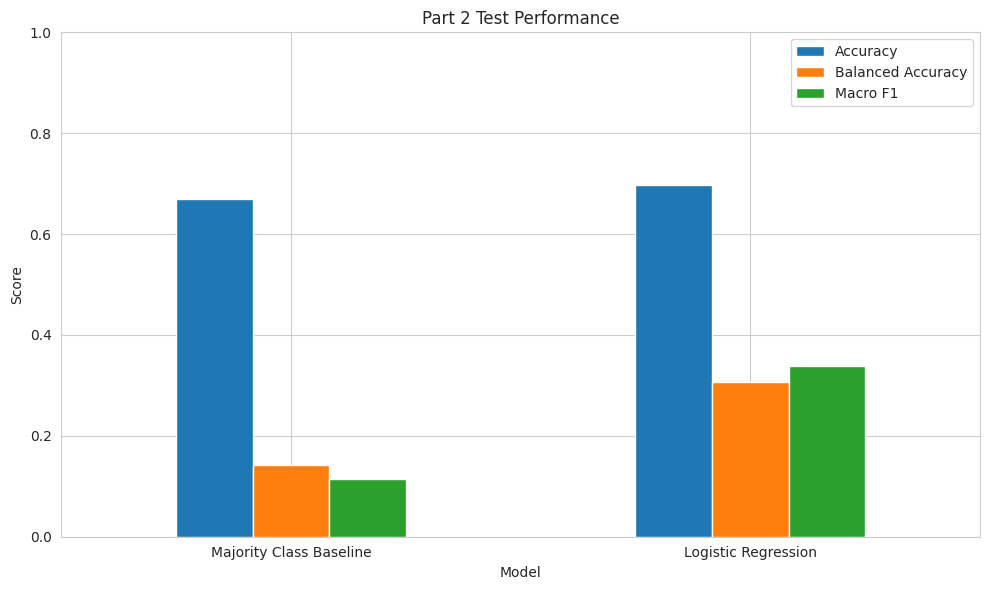

In [28]:
majority_result["Log Loss"] = majority_loss
logistic_result["Log Loss"] = logistic_loss

part2_results_df = pd.DataFrame([
    majority_result,
    logistic_result
])

display(part2_results_df.round(4))

plot_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1"
]

part2_results_df.set_index("Model")[plot_metrics].plot(
    kind="bar",
    figsize=(10, 6),
    ylim=(0, 1),
    rot=0
)

plt.title("Part 2 Test Performance")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

### Part 2 analysis

The Majority Class Baseline achieved 66.86% accuracy, but its balanced accuracy and macro-F1 were only 14.29% and 11.45%. This is because it ignored the image information and predicted only the most frequent class.

Logistic Regression improved the accuracy to 69.68%, balanced accuracy to 30.67%, and macro-F1 to 33.94%. Its log loss was also much lower than the baseline (0.8202 compared with 11.9456), indicating more reliable probability predictions. However, Logistic Regression still struggled with minority classes because the dataset is imbalanced. In addition, flattening the images removes their spatial structure, so Logistic Regression cannot learn lesion shapes and textures as effectively as CNN-based models.


In [22]:
# Handle Class Imbalance


classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, weights)
}
print(class_weights)

{0: 4.34297052154195, 1: 2.813441057656996, 2: 1.30600068189567, 3: 12.436688311688311, 4: 0.21358871417419426, 5: 1.2711133233781318, 6: 10.040629095674968}


## Random Forest Model

In [23]:
# Train Random Forest Classifier


X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

print("Random Forest training shape:", X_train_rf.shape)
print("Random Forest test shape:", X_test_rf.shape)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train)


Random Forest training shape: (7661, 3072)
Random Forest test shape: (1916, 3072)


RandomForestClassifier(class_weight={0: 4.34297052154195, 1: 2.813441057656996,
                                     2: 1.30600068189567, 3: 12.436688311688311,
                                     4: 0.21358871417419426,
                                     5: 1.2711133233781318,
                                     6: 10.040629095674968},
                       n_estimators=200, n_jobs=-1, random_state=42)

Random Forest Accuracy: 0.7056367432150313
Random Forest Balanced Accuracy: 0.243277303758759

Classification Report:
                               precision    recall  f1-score   support

            actinic_keratoses       0.56      0.16      0.25        63
         basal_cell_carcinoma       0.46      0.21      0.29        98
benign_keratosis-like_lesions       0.55      0.27      0.36       210
               dermatofibroma       1.00      0.05      0.09        22
             melanocytic_Nevi       0.72      0.98      0.83      1281
                     melanoma       0.64      0.03      0.06       215
             vascular_lesions       0.00      0.00      0.00        27

                     accuracy                           0.71      1916
                    macro avg       0.56      0.24      0.27      1916
                 weighted avg       0.67      0.71      0.63      1916



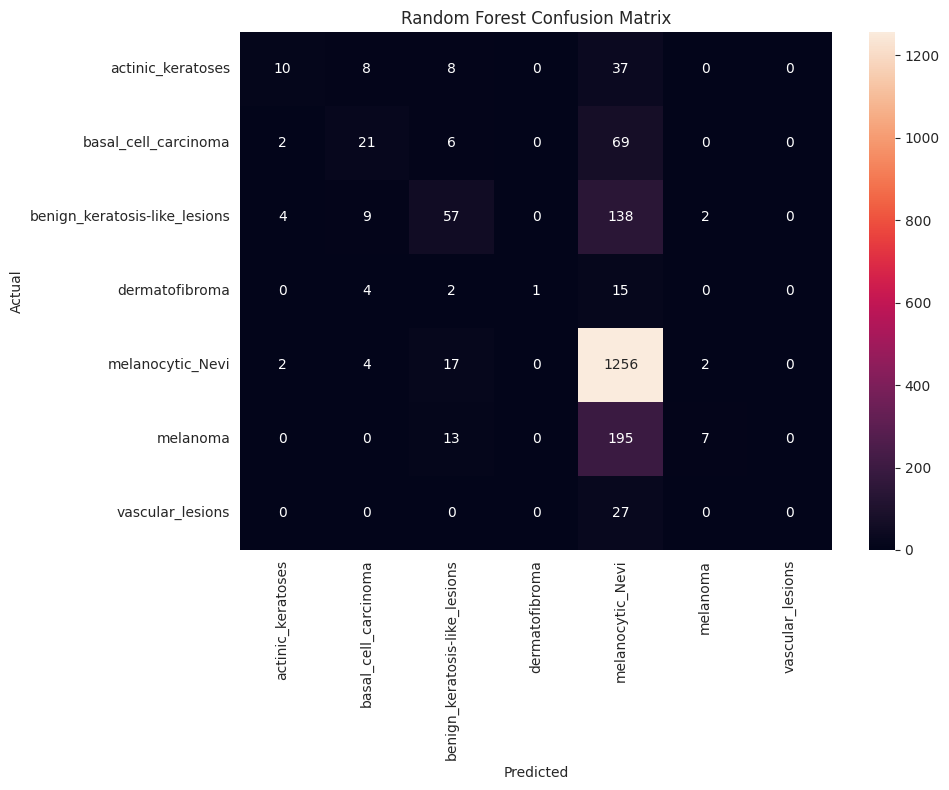

In [24]:
# Evaluate Random Forest Model

rf_predictions = rf_model.predict(X_test_rf)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Random Forest Balanced Accuracy:", balanced_accuracy_score(y_test, rf_predictions))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, rf_predictions, labels=np.arange(len(class_names)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## LSTM Model

In [25]:
# Train LSTM Classifier

RUN_LSTM = True

if RUN_LSTM:
    import tensorflow as tf

    tf.random.set_seed(42)

    # Treat image rows as sequence steps; width × channels are features.
    X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

    lstm_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=X_train_lstm.shape[1:]),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(len(class_names), activation="softmax"),
    ])

    lstm_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    lstm_model.fit(
        X_train_lstm,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=64,
        class_weight=class_weights,
        verbose=1,
    )

    test_loss, test_accuracy = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)
    print("LSTM test loss:", test_loss)
    print("LSTM test accuracy:", test_accuracy)
else:
    print("LSTM training skipped. Set RUN_LSTM = True to enable it.")

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.1616 - loss: 2.0032 - val_accuracy: 0.3425 - val_loss: 1.9140
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.3301 - loss: 1.9670 - val_accuracy: 0.4070 - val_loss: 1.8368
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.3743 - loss: 1.8976 - val_accuracy: 0.4892 - val_loss: 1.5928
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4112 - loss: 1.8329 - val_accuracy: 0.4827 - val_loss: 1.4965
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.4337 - loss: 1.8032 - val_accuracy: 0.5160 - val_loss: 1.4118
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4370 - loss: 1.7637 - val_accuracy: 0.4566 - val_loss: 1.6052
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.4510 - loss: 1.7380 - val_accuracy: 0.4599 - val_loss: 1.6291
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4530 - loss: 1.7187 - val_accuracy: 0.4866 - v

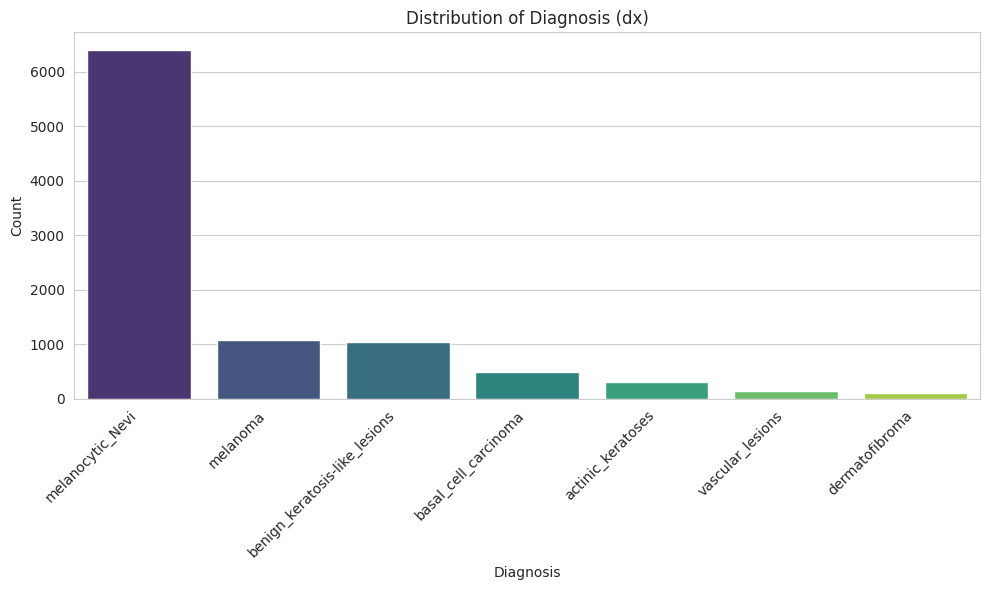

In [26]:
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()